# Watt's the Cost — Exploratory Data Analysis
#### Julia Craciun
---
Now that the data has been cleaned and consolidated, we explore its structure, distributions, and relationships before modelling.

In [59]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import numpy as np
import pgeocode
import plotly.express as px

# Prevent matplotlib from interpreting $ signs as LaTeX
mpl.rcParams['text.usetex'] = False
mpl.rcParams['axes.formatter.use_mathtext'] = False

sns.set_theme(style='whitegrid', palette='muted')

def clean_label(s):
    """Strip characters that trigger matplotlib's math parser."""
    return s.replace('$', '').replace('_', ' ')

## 1. Load Data

Below, we read in the dataset and output the number of rows and columns. 

In [3]:
df = pd.read_parquet(r'data/cleaned_data.parquet', engine='fastparquet')
print(f'Shape: {df.shape}')
df.head()

Shape: (181536, 42)


,zip,households,moe_households,households_less_than_$10k,moe_households_less_than_$10k,households_$10k_to_$14k,moe_households_$10k_to_$14k,households_$15k_to_$24k,moe_households_$15k_to_$24k,households_$25k_to_$34k,...,n20_49,n50_99,n100_249,n250_499,n500_999,n1000,service_type,ownership,rate_type_index,rate
0,1002,9715,427,9.7,3.2,5.5,2.0,9.2,3.6,5.9,...,145.0,25.0,0.0,0.0,0.0,0.0,Delivery,Investor Owned,2,0.142767
1,1005,1688,185,1.0,1.6,4.4,5.6,4.1,5.3,4.0,...,13.0,3.0,0.0,0.0,0.0,0.0,Delivery,Investor Owned,2,0.142767
2,1007,6429,359,2.7,1.5,2.9,1.6,6.2,3.1,4.6,...,36.0,0.0,3.0,0.0,0.0,0.0,Delivery,Investor Owned,2,0.142767
3,1009,367,151,10.6,12.7,4.6,7.8,14.2,21.2,9.5,...,0.0,0.0,0.0,0.0,0.0,0.0,Delivery,Investor Owned,2,0.142767
4,1010,1479,110,2.6,2.2,3.9,4.4,5.8,3.4,5.3,...,0.0,0.0,0.0,0.0,0.0,0.0,Delivery,Investor Owned,2,0.142767


## 2. Dataset Overview

### 2.1 Schema and Data Types

The dataset is the result of joining four sources on ZIP code:

| Feature Group | Columns | Description |
|---|---|---|
| **Identifier** | `zip` | US ZIP code (stored as int64 — leading zeros lost for New England ZIPs) |
| **Income** | `households`, `households_*`, `moe_*` | ACS S1901: total households, % in each income bracket, median/mean income, margins of error |
| **Business** | `est`, `n<5` … `n1000` | ZBP 2023: establishment count and counts by employee size class |
| **Utility** | `service_type`, `ownership` | OpenEI: whether the utility is Bundled/Delivery/Energy and its ownership type |
| **Target** | `rate` | Electricity rate in $/kWh |
| **Rate type** | `rate_type_index` | 0 = commercial, 1 = industrial, 2 = residential |

In [4]:
print(df.dtypes)
print(f'\nTotal rows: {len(df):,}')
print(f'Unique ZIPs: {df["zip"].nunique():,}')

zip                                                                      int64
households                                                               int64
moe_households                                                           int64
households_less_than_$10k                                              float64
moe_households_less_than_$10k                                          float64
households_$10k_to_$14k                                                float64
moe_households_$10k_to_$14k                                            float64
households_$15k_to_$24k                                                float64
moe_households_$15k_to_$24k                                            float64
households_$25k_to_$34k                                                float64
moe_households_$25k_to_$34k                                            float64
households_$35k_to_$49k                                                float64
moe_households_$35k_to_$49k                         

### 2.2 Missing Values

We verify that there are no `NaNs` left in the dataset before we proceed. 

In [5]:
df.isnull().any()

zip                                                                    False
households                                                             False
moe_households                                                         False
households_less_than_$10k                                              False
moe_households_less_than_$10k                                          False
households_$10k_to_$14k                                                False
moe_households_$10k_to_$14k                                            False
households_$15k_to_$24k                                                False
moe_households_$15k_to_$24k                                            False
households_$25k_to_$34k                                                False
moe_households_$25k_to_$34k                                            False
households_$35k_to_$49k                                                False
moe_households_$35k_to_$49k                                            False

### 2.3 ZIP Code Uniqueness

ZIP codes are not unique — each ZIP can appear multiple times because:
1. Multiple utility providers may serve the same ZIP
2. Each utility files separate rates for residential (2), industrial (1), and commercial (0) customers

This means the income and business features are repeated across rows that share a ZIP.

In [9]:
print(f'Unique ZIPs: {df["zip"].nunique():,}')
print(f'Total rows:  {len(df):,}')
print(f'Avg rows per ZIP: {len(df)/df["zip"].nunique():.1f}')

print('\nRows per ZIP (top 10 counts):')
print(df.groupby('zip').size().value_counts().head(10))

print('\nZIPs with most rows:')
print(df['zip'].value_counts().head(5))

Unique ZIPs: 27,808
Total rows:  181,536
Avg rows per ZIP: 6.5

Rows per ZIP (top 10 counts):
6     10821
3      6183
9      3358
12     1847
5      1817
8      1532
11      627
15      430
4       230
2       217
Name: count, dtype: int64

ZIPs with most rows:
zip
17257    27
10524    24
14895    23
98926    23
7436     21
Name: count, dtype: int64


We take the most popular zip code as an example to see exactly how much each of the rows differ. 

In [ ]:
top_zip = df['zip'].value_counts().index[0]
filtered = df[df['zip'] == top_zip]
print(f'ZIP {top_zip} — unique values per column:')
for col in filtered.columns:
    print(f'  {col}: {filtered[col].unique()}')

ZIP 17257 — unique values per column:
  zip: [17257]
  households: [10665]
  moe_households: [564]
  households_less_than_$10k: [2.]
  moe_households_less_than_$10k: [0.8]
  households_$10k_to_$14k: [3.8]
  moe_households_$10k_to_$14k: [1.9]
  households_$15k_to_$24k: [8.]
  moe_households_$15k_to_$24k: [2.9]
  households_$25k_to_$34k: [7.7]
  moe_households_$25k_to_$34k: [2.5]
  households_$35k_to_$49k: [11.5]
  moe_households_$35k_to_$49k: [3.1]
  households_$50k_to_$74k: [20.6]
  moe_households_$50k_to_$74k: [4.1]
  households_$75k_to_$99k: [13.6]
  moe_households_$75k_to_$99k: [2.5]
  households_$100k_to_$149k: [20.7]
  moe_households_$100k_to_$149k: [3.1]
  households_$150k_to_$199k: [6.8]
  moe_households_$150k_to_$199k: [1.8]
  households_$200k_or_more: [5.3]
  moe_households_$200k_or_more: [1.6]
  households_median_income: [71504.]
  moe_households_median_income: [4078.]
  households_mean_income: [91126.]
  moe_households_mean_income: [9276.]
  households_percent_allocated_hous

Above, we see that there are instances where multiple of the same features map to different rates. This might inflate errors and reduce predictive power. As a result, we will likely aggregate rows that same the share features, but different outcomes before the modeling process. 

## 3. Target Variable: `rate`

The target is `rate` ($/kWh), with `rate_type_index` indicating whether it is a residential (2), commercial (0), or industrial (1) rate. Zero values were removed during cleaning as they represent missing or inapplicable rates.

In [6]:
print(df[['rate']].describe())

                rate
count  181536.000000
mean        0.116159
std         0.064079
min         0.001273
25%         0.076230
50%         0.110670
75%         0.143107
max         0.644231


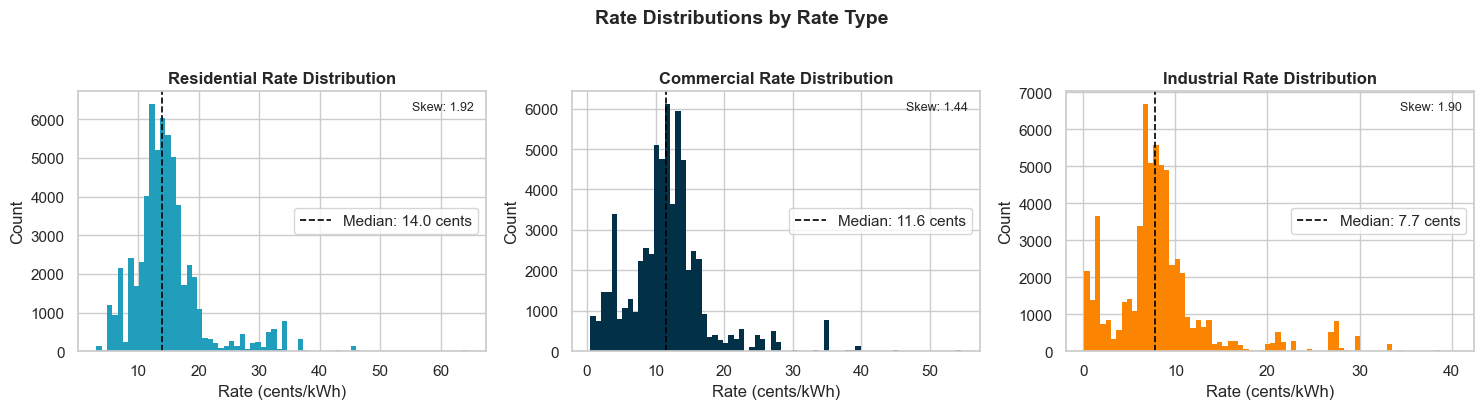

In [21]:
# Rate distribution split by rate_type_index
rate_labels = {0: 'Commercial', 1: 'Industrial', 2: 'Residential'}
colors = {0: '#023047', 1: '#fb8500', 2: '#219ebc'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, ax in zip([2, 0, 1], axes):
    data = df[df['rate_type_index'] == idx]['rate'] * 100
    ax.hist(data, bins=70, color=colors[idx], edgecolor='none')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2,
               label=f'Median: {data.median():.1f} cents')
    ax.set_title(f'{rate_labels[idx]} Rate Distribution', fontweight='bold')
    ax.set_xlabel('Rate (cents/kWh)')
    ax.set_ylabel('Count')
    ax.text(0.97, 0.93, f'Skew: {data.skew():.2f}', transform=ax.transAxes,
            ha='right', fontsize=9)
    ax.legend()

plt.suptitle('Rate Distributions by Rate Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
df[['zip', 'rate', 'rate_type_index', 'ownership', 'service_type']].sort_values('rate', ascending=False)[0:20]


,zip,rate,rate_type_index,ownership,service_type
173316,99785,0.644231,2,Cooperative,Bundled
173309,99770,0.644231,2,Cooperative,Bundled
173272,99662,0.644231,2,Cooperative,Bundled
173271,99658,0.644231,2,Cooperative,Bundled
173270,99657,0.644231,2,Cooperative,Bundled
173310,99771,0.644231,2,Cooperative,Bundled
173269,99655,0.644231,2,Cooperative,Bundled
173311,99772,0.644231,2,Cooperative,Bundled
173313,99778,0.644231,2,Cooperative,Bundled
173247,99581,0.644231,2,Cooperative,Bundled


All three of the distributions are right-skewed. Residential rates are highest (median ~14 cents), commercial lower (~12 cents), and industrial lowest (~8 cents). It appears that the highest rates are associated with Alaskan zip codes. 

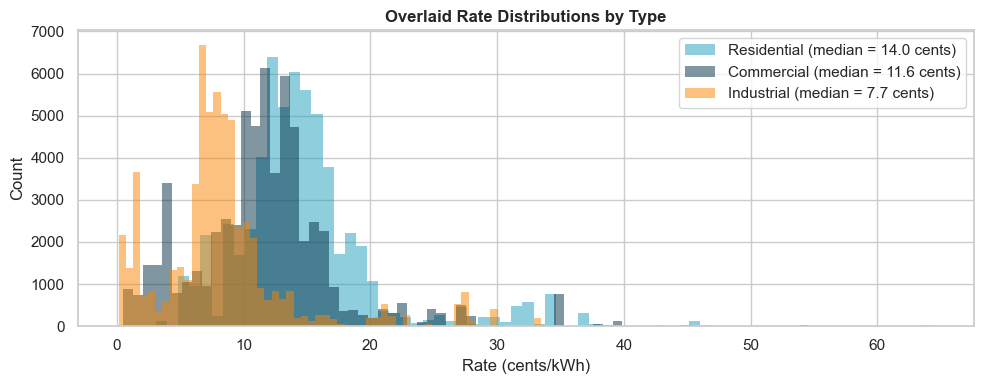

In [25]:
# overlaid density for direct comparison
fig, ax = plt.subplots(figsize=(10, 4))
for idx in [2, 0, 1]:
    data = df[df['rate_type_index'] == idx]['rate'] * 100
    ax.hist(data, bins=70, alpha=0.5, color=colors[idx],
            label=f'{rate_labels[idx]} (median = {data.median():.1f} cents)', edgecolor='none')

ax.set_xlabel('Rate (cents/kWh)')
ax.set_ylabel('Count')
ax.set_title('Overlaid Rate Distributions by Type', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Categorical Features

### 4.1 Service Type

- **Bundled**: utility handles generation, transmission, and delivery — the rate is all-in
- **Delivery**: deregulated markets where the utility only charges for the wire; supply is billed separately
- **Energy**: supply-only charge with no delivery component (7 rows — negligible)

For predicting what a customer actually pays, Bundled is the most meaningful service type.

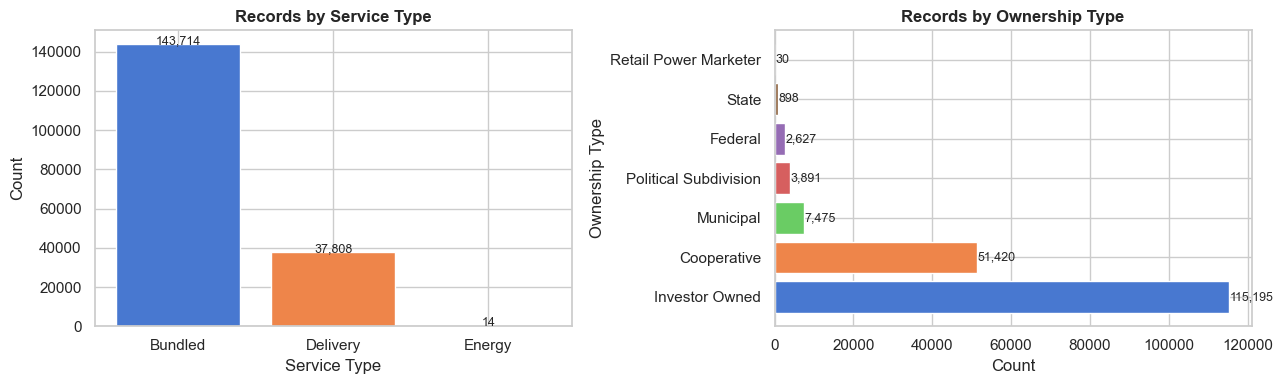

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

svc = df['service_type'].value_counts()
axes[0].bar(svc.index, svc.values, color=sns.color_palette('muted', len(svc)))
axes[0].set_title('Records by Service Type', fontweight='bold')
axes[0].set_xlabel('Service Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(svc.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

own = df['ownership'].value_counts()
axes[1].barh(own.index, own.values, color=sns.color_palette('muted', len(own)))
axes[1].set_title('Records by Ownership Type', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Ownership Type')
for i, v in enumerate(own.values):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

It appears that most overnship is Investor Owned, followed by Cooperative ownership. 

### 4.2 Rate by Ownership Type

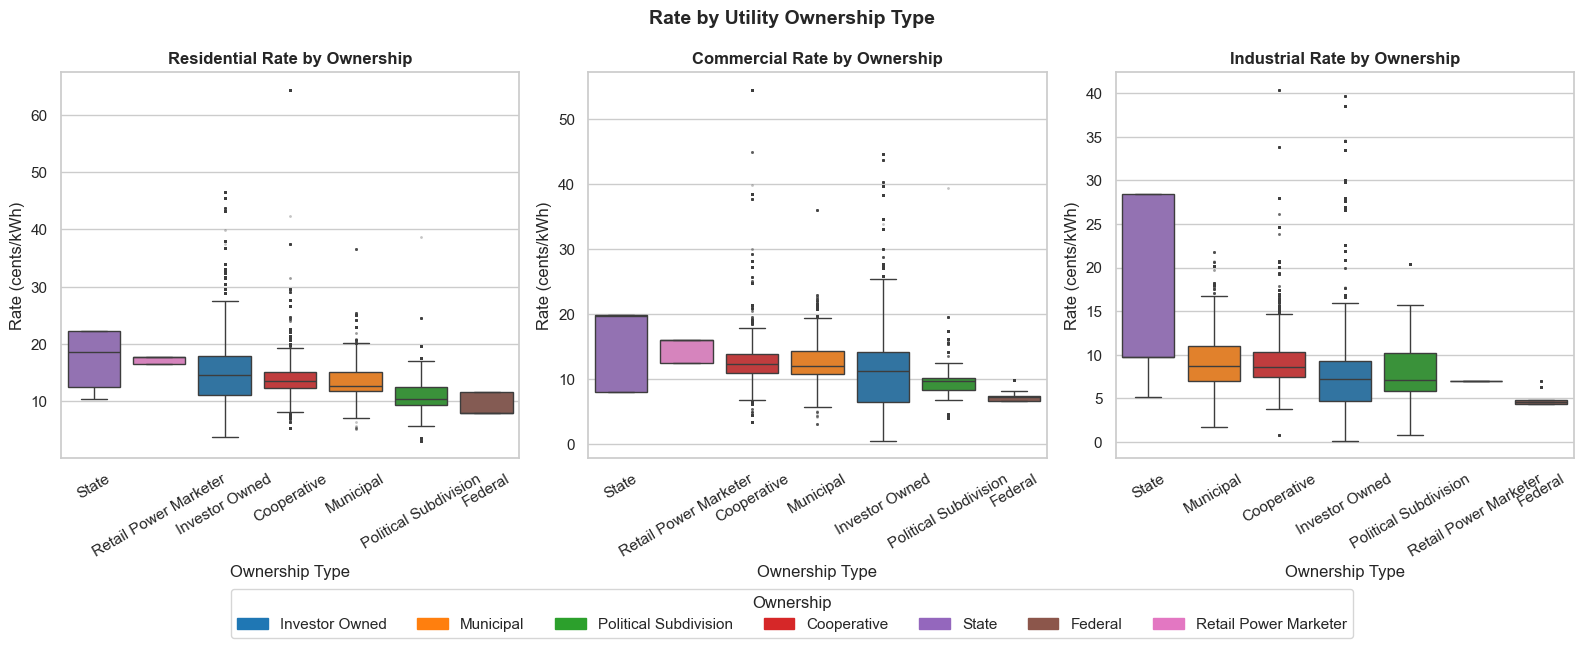

In [38]:
ownership_categories = df['ownership'].unique().tolist()
palette = dict(zip(ownership_categories, sns.color_palette('tab10', len(ownership_categories))))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for idx, ax in zip([2, 0, 1], axes):
    data = df[df['rate_type_index'] == idx][['ownership', 'rate']].copy()
    data['rate'] = data['rate'] * 100
    order = data.groupby('ownership')['rate'].median().sort_values(ascending=False).index.tolist()

    sns.boxplot(data=data, x='ownership', y='rate', order=order, ax=ax,
                hue='ownership', hue_order=order, palette=palette, legend=False,
                flierprops=dict(marker='.', markersize=2, alpha=0.3))

    ax.set_title(f'{rate_labels[idx]} Rate by Ownership', fontweight='bold')
    ax.set_xlabel('Ownership Type')  # explicit label on all three
    ax.set_ylabel('Rate (cents/kWh)')
    ax.tick_params(axis='x', rotation=30)


handles = [plt.Rectangle((0,0),1,1, color=palette[o]) for o in ownership_categories]
fig.legend(handles, ownership_categories, title='Ownership',
           loc='lower center', ncol=len(ownership_categories), bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Rate by Utility Ownership Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Income Features

### 5.1 Income Bracket Distribution

Note: the `households_$X_to_$Y` columns represent **percentages** of households in each bracket, not raw counts.

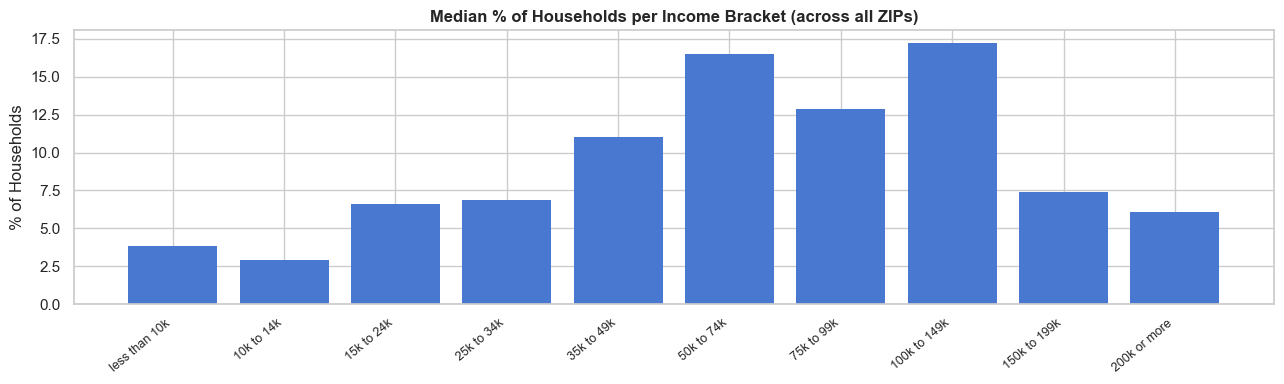

In [39]:
income_cols = [c for c in df.columns if
               (c.startswith('households_') and 'moe' not in c
                and c not in ['households','households_median_income',
                              'households_mean_income',
                              'households_percent_allocated_household_income_in_the_past_12_months'])]

medians = df[income_cols].median()
clean_labels = [clean_label(c).replace('households ','') for c in medians.index]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(medians)), medians.values, color='#4878CF', edgecolor='none')
ax.set_xticks(range(len(medians)))
ax.set_xticklabels(clean_labels, rotation=40, ha='right', fontsize=9)
ax.set_title('Median % of Households per Income Bracket (across all ZIPs)', fontweight='bold')
ax.set_ylabel('% of Households')
plt.tight_layout()
plt.show()

There appears to be one cluster around 50k-74k and another around 100k-149k. Low-income brackets (<25k) are small, reflecting that ZIPs tend to be middle-income on average.

### 5.2 Median Income vs Rate

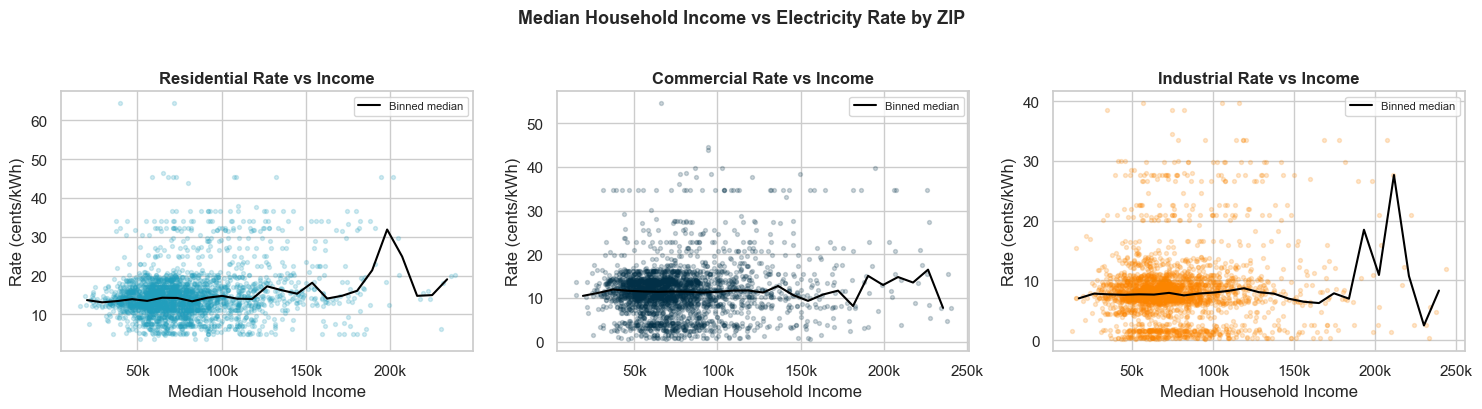

In [43]:
sample = df.sample(min(8000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, ax in zip([2, 0, 1], axes):
    s = sample[sample['rate_type_index'] == idx]
    ax.scatter(s['households_median_income'], s['rate'] * 100,
               alpha=0.2, s=8, color=colors[idx])
    # Binned trend
    s = s.copy()
    s['bin'] = pd.cut(s['households_median_income'], bins=25)
    trend = s.groupby('bin')['rate'].median() * 100
    centers = [iv.mid for iv in trend.index]
    ax.plot(centers, trend.values, color='black', linewidth=1.5, label='Binned median')
    ax.set_xlabel('Median Household Income')
    ax.set_ylabel('Rate (cents/kWh)')
    ax.set_title(f'{rate_labels[idx]} Rate vs Income', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.legend(fontsize=8)

plt.suptitle('Median Household Income vs Electricity Rate by ZIP', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Income alone is a weak predictor, since there is high variance at every income level.

## 6. Business Features

### 6.1 Establishment Size Class Distribution

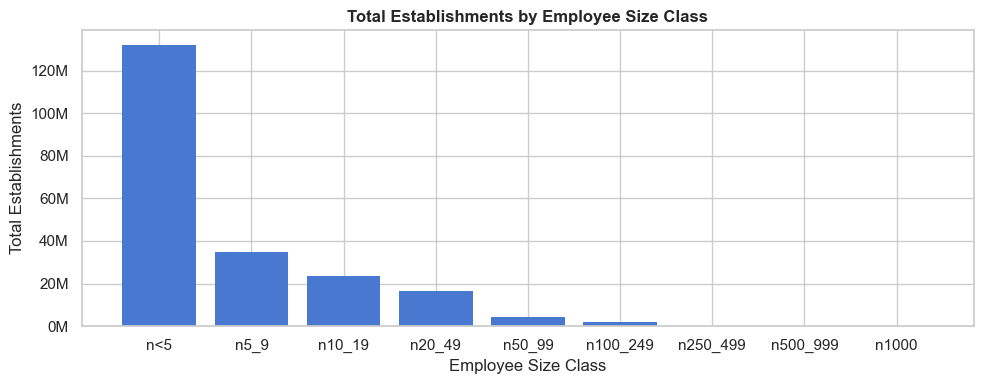

In [45]:
size_cols = ['n<5','n5_9','n10_19','n20_49','n50_99','n100_249','n250_499','n500_999','n1000']
available = [c for c in size_cols if c in df.columns]

totals = df[available].sum()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(totals.index, totals.values, color='#4878CF', edgecolor='none')
ax.set_title('Total Establishments by Employee Size Class', fontweight='bold')
ax.set_xlabel('Employee Size Class')
ax.set_ylabel('Total Establishments')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

The vast majority of US businesses have fewer than 5 employees. The distribution drops off sharply, meaning the n<5 column will likely dominate any business-feature signal. Therefore, a log-transform might  help during modelling.

### 6.2 Business Density vs Rate

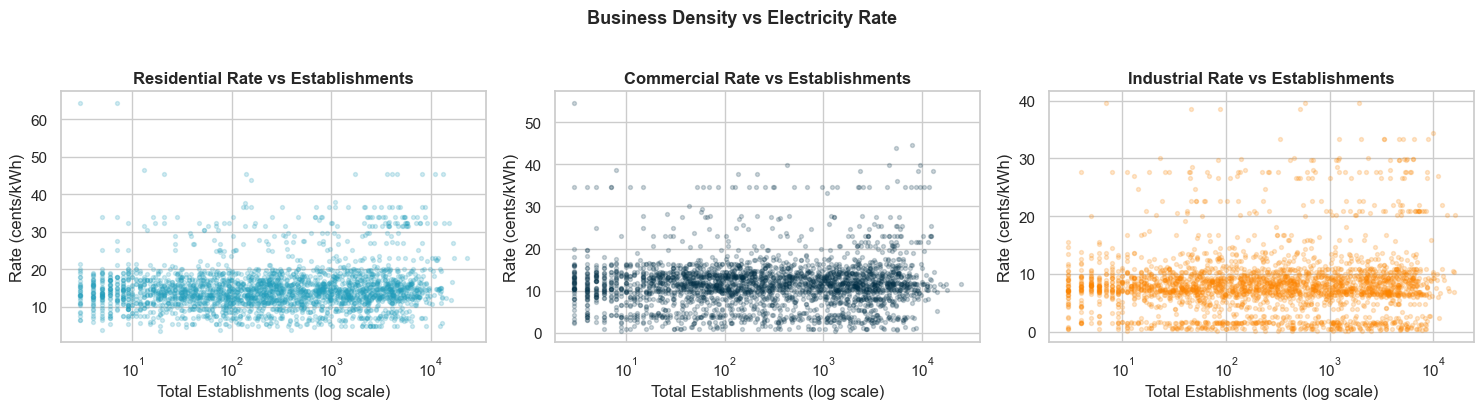

In [46]:
sample = df.sample(min(8000, len(df)), random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, ax in zip([2, 0, 1], axes):
    s = sample[sample['rate_type_index'] == idx]
    ax.scatter(s['est'], s['rate'] * 100, alpha=0.2, s=8, color=colors[idx])
    ax.set_xscale('log')
    ax.set_xlabel('Total Establishments (log scale)')
    ax.set_ylabel('Rate (cents/kWh)')
    ax.set_title(f'{rate_labels[idx]} Rate vs Establishments', fontweight='bold')

plt.suptitle('Business Density vs Electricity Rate', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Data Quality: Margin of Error Analysis

The ACS income columns come with margins of error (MOE). A high MOE-to-value ratio means that estimate is statistically unreliable for that ZIP.

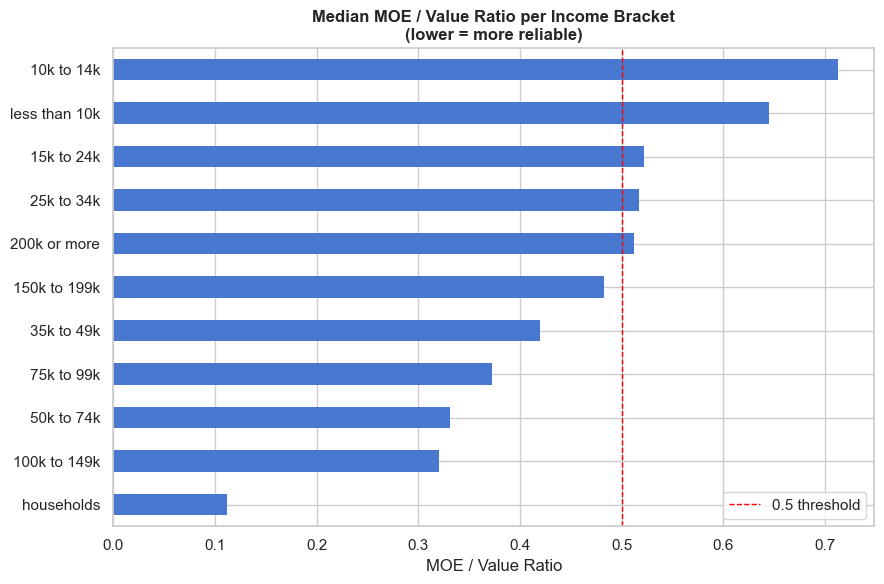

In [52]:
moe_cols = [c for c in df.columns if c.startswith('moe_') and 'income' not in c]
val_cols = [c.replace('moe_', '') for c in moe_cols]

ratios = {}
for moe, val in zip(moe_cols, val_cols):
    if val in df.columns:
        ratio = (df[moe] / df[val].replace(0, float('nan'))).median()
        ratios[clean_label(val).replace('households ','')] = ratio

fig, ax = plt.subplots(figsize=(9, 6))
pd.Series(ratios).sort_values().plot.barh(ax=ax, color='#4878CF', edgecolor='none')
ax.set_title('Median MOE / Value Ratio per Income Bracket\n(lower = more reliable)', fontweight='bold')
ax.set_xlabel('MOE / Value Ratio')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='0.5 threshold')
ax.legend()
plt.tight_layout()
plt.show()

Brackets with ratios above 0.5 have margins of error more than half their estimated value. Very low-income brackets appear to be less reliable, potentially due to a smaller sample.  

## 8. Correlation Analysis

### 8.1 Feature Correlations with Rate

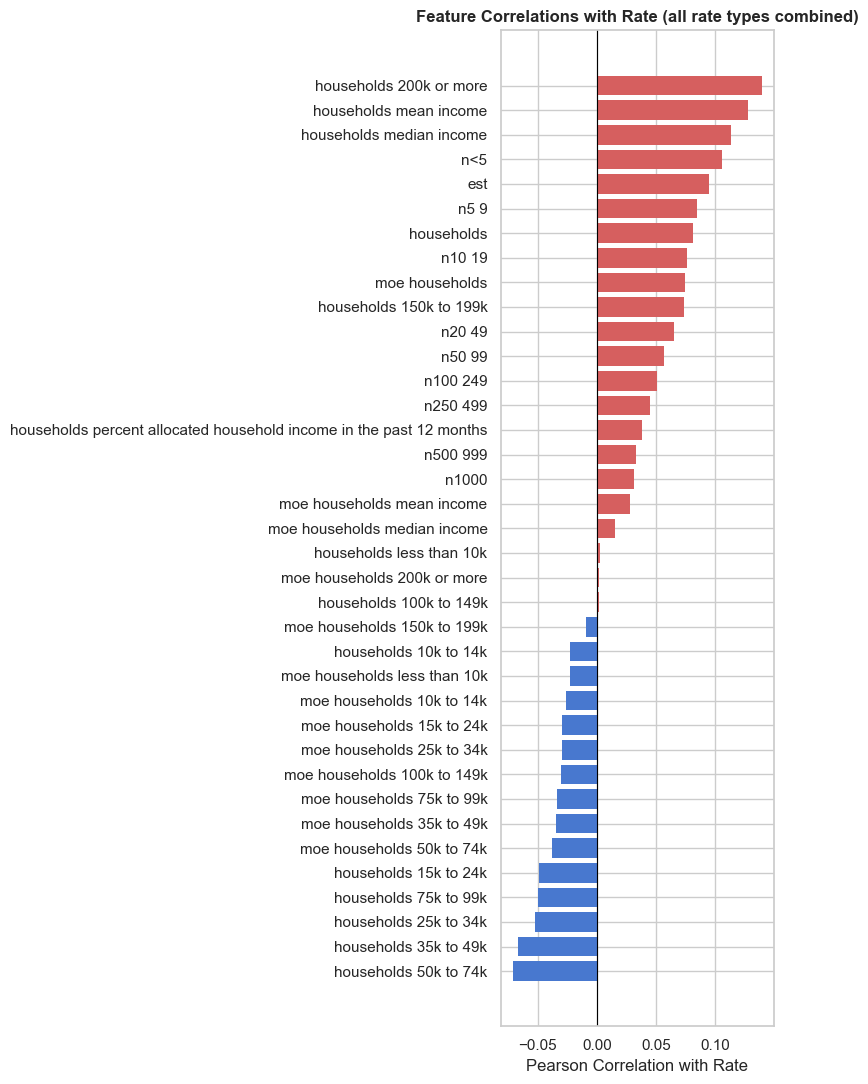

In [54]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
exclude = ['zip', 'rate', 'rate_type_index']
numeric_cols = [c for c in numeric_cols if c not in exclude]

corrs = df[numeric_cols + ['rate']].corr()['rate'].drop('rate').sort_values()
clean_idx = [clean_label(c) for c in corrs.index]

fig, ax = plt.subplots(figsize=(8, 11))
bar_colors = ['#D65F5F' if v > 0 else '#4878CF' for v in corrs.values]
ax.barh(clean_idx, corrs.values, color=bar_colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Rate')
ax.set_title('Feature Correlations with Rate (all rate types combined)', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Feature Heatmap (Top Correlators)

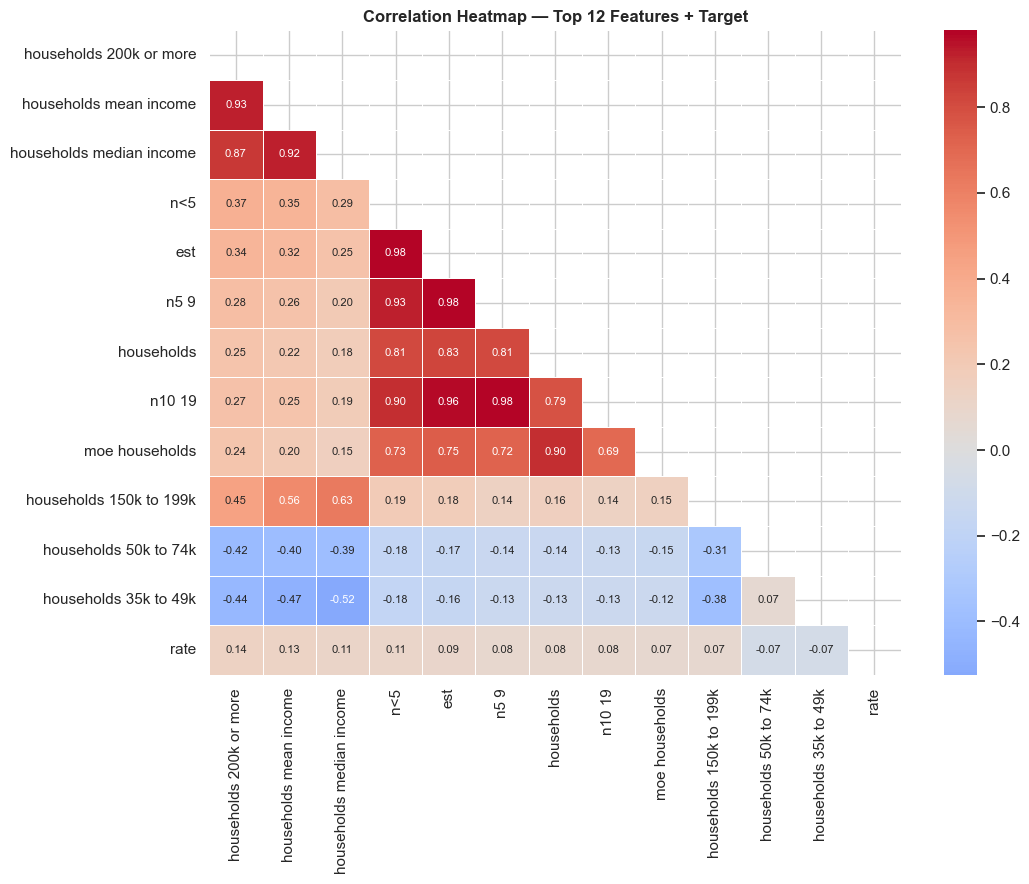

In [55]:
top_feats = corrs.abs().sort_values(ascending=False).head(12).index.tolist()
heatmap_df = df[top_feats + ['rate']].corr()
heatmap_df.columns = [clean_label(c) for c in heatmap_df.columns]
heatmap_df.index = heatmap_df.columns

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(heatmap_df, dtype=bool))
sns.heatmap(heatmap_df, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Top 12 Features + Target', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Geographic Distribution

### 9.1 ZIP Coverage by State

In [60]:
nomi = pgeocode.Nominatim('us')
zip_list = df['zip'].astype(str).str.zfill(5).unique().tolist()
geo = nomi.query_postal_code(zip_list)[['postal_code','state_code']].dropna()
state_counts = geo.groupby('state_code').size().reset_index(name='zip_count')

fig = px.choropleth(state_counts, locations='state_code', locationmode='USA-states',
                    color='zip_count', scope='usa', color_continuous_scale='Blues',
                    title='Number of ZIP Codes Covered per State')
fig.update_layout(margin={'r':0,'t':30,'l':0,'b':0})
fig.show()

### 9.2 Median Residential Rate by State

In [62]:
geo_df = geo.copy()
geo_df.columns = ['zip_str', 'state_code']
df['zip_str'] = df['zip'].astype(str).str.zfill(5)

res_df = df[df['rate_type_index'] == 2].copy()
merged = res_df.merge(geo_df, left_on='zip_str', right_on='zip_str')
state_rates = merged.groupby('state_code')['rate'].median().reset_index()
state_rates['rate_cents'] = state_rates['rate'] * 100

fig = px.choropleth(state_rates, locations='state_code', locationmode='USA-states',
                    color='rate_cents', scope='usa', color_continuous_scale='RdYlGn_r',
                    title='Median Residential Electricity Rate by State (cents/kWh)',
                    labels={'rate_cents': 'cents/kWh'})
fig.update_layout(margin={'r':0,'t':30,'l':0,'b':0})
fig.show()

California, Hawaii, and Alaska have the highest rates. The Southeast and Northwest tend to have lower rates.

## 10. Census Imputation Flag

`households_percent_allocated_household_income_in_the_past_12_months` measures what % of households had their income statistically imputed rather than reported. High values indicate lower data quality for that ZIP.

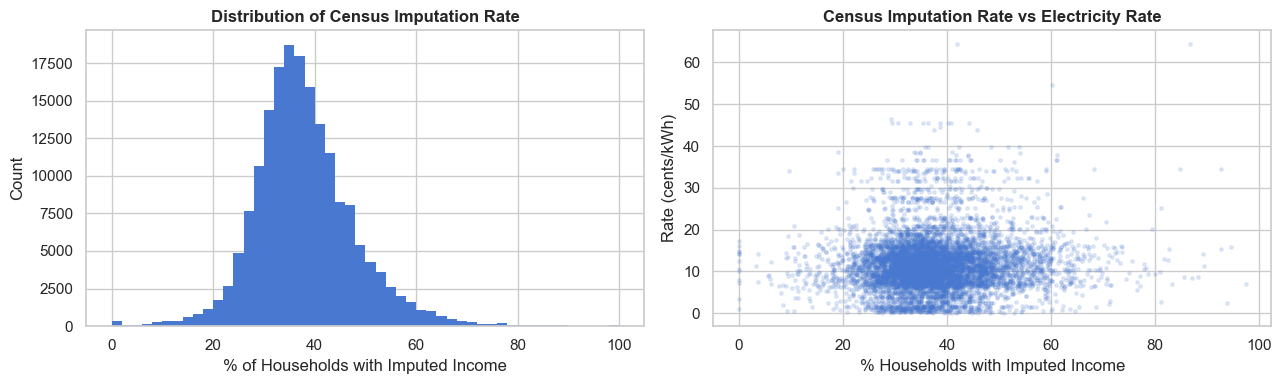

In [63]:
col = 'households_percent_allocated_household_income_in_the_past_12_months'
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df[col].hist(bins=50, ax=axes[0], color='#4878CF', edgecolor='none')
axes[0].set_title('Distribution of Census Imputation Rate', fontweight='bold')
axes[0].set_xlabel('% of Households with Imputed Income')
axes[0].set_ylabel('Count')

sample = df.sample(min(8000, len(df)), random_state=42)
axes[1].scatter(sample[col], sample['rate'] * 100, alpha=0.15, s=6, color='#4878CF')
axes[1].set_xlabel('% Households with Imputed Income')
axes[1].set_ylabel('Rate (cents/kWh)')
axes[1].set_title('Census Imputation Rate vs Electricity Rate', fontweight='bold')

plt.tight_layout()
plt.show()

No strong relationship with rate is visible, suggesting data quality (as measured by imputation) is not systematically biased toward high- or low-rate areas.